### 1. Carga de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, torch, gc

esqueleto = pd.read_parquet('/content/drive/MyDrive/TFM/favorita_panel_corregido.parquet')
print(esqueleto.shape)

_torch_load_original = torch.serialization.load
def _torch_load_patched(*args, **kwargs):
    kwargs['weights_only'] = False
    return _torch_load_original(*args, **kwargs)
torch.load = _torch_load_patched

!pip install pytorch-forecasting pytorch-lightning lightning -q

import pytorch_forecasting.data.encoders as pf_encoders
torch.serialization.add_safe_globals([
    pf_encoders.GroupNormalizer, pf_encoders.TorchNormalizer,
    pf_encoders.NaNLabelEncoder, pf_encoders.EncoderNormalizer, pf_encoders.MultiNormalizer,
])

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer

print('GPU disponible:', torch.cuda.is_available())

Mounted at /content/drive
(4804366, 22)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.9 MB/s eta 0:00:00
GPU disponible: True


### 2. Preparación de variables

In [2]:
if 'type' in esqueleto.columns:
    esqueleto = esqueleto.rename(columns={'type': 'store_type'})
for col in ['store_nbr', 'item_nbr', 'city', 'state', 'store_type', 'cluster', 'family', 'class', 'perishable']:
    esqueleto[col] = esqueleto[col].astype(str)

### 3. Partición de datos y ponderación por volumen

In [3]:
fecha_max = esqueleto['date'].max()
test_inicio = fecha_max - pd.Timedelta(days=60)
val_inicio = test_inicio - pd.Timedelta(days=60)

train = esqueleto[esqueleto['date'] < val_inicio]
val = esqueleto[(esqueleto['date'] >= val_inicio) & (esqueleto['date'] < test_inicio)]
print('Train:', train.shape, '| Val:', val.shape)

volumen_por_serie = esqueleto.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform('mean')
esqueleto['peso_muestra'] = 1 / np.sqrt(volumen_por_serie + 0.1)
esqueleto['peso_muestra'] = esqueleto['peso_muestra'] / esqueleto['peso_muestra'].mean()

Train: (4322665, 22) | Val: (238860, 22)


### 4. Reconstrucción de TimeSeriesDataSet

In [4]:
max_encoder_length, max_prediction_length = 90, 30
training_cutoff = train['time_idx'].max()

training = TimeSeriesDataSet(
    esqueleto[esqueleto.time_idx <= training_cutoff],
    time_idx="time_idx", target="unit_sales", group_ids=["store_nbr", "item_nbr"],
    max_encoder_length=max_encoder_length, max_prediction_length=max_prediction_length,
    static_categoricals=["city", "state", "store_type", "cluster", "family", "class", "perishable"],
    time_varying_known_reals=["time_idx", "year", "month", "day_of_week", "is_weekend",
                               "es_feriado", "onpromotion", "edad"],
    time_varying_unknown_reals=["unit_sales", "dcoilwtico"],
    target_normalizer=GroupNormalizer(groups=["store_nbr", "item_nbr"], transformation="log1p"),
    weight="peso_muestra", add_relative_time_idx=True, add_target_scales=True,
    add_encoder_length=True, allow_missing_timesteps=False,
)

print('TimeSeriesDataSet reconstruido, listo para cargar el modelo.')

/usr/local/lib/python3.13/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 88 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__store_nbr': '1', '__group_id__item_nbr': '1428779'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2002136'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2027777'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2027827'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2053590'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2053610'}, {'__group_id__store_nbr': '1', '__group_id__item_nbr': '2053614'}, {'__group_id__store_nbr': '10', '__group_id__item_nbr': '2033805'}, {'__group_id__store_nbr': '10', '__group_id__item_nbr': '2053590'}, {'__group_id__store_nbr': '1

TimeSeriesDataSet reconstruido, listo para cargar el modelo.


### 5. Carga del mejor modelo TFT

In [5]:
tft_mejor = TemporalFusionTransformer.load_from_checkpoint('/content/drive/MyDrive/TFM/tft_t1_v2.ckpt')
print('Modelo cargado. hidden_size:', tft_mejor.hparams.hidden_size)

Modelo cargado. hidden_size: 30


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


### 6. Muestra para interpretación

 Se usa una muestra aleatoria de 500 series (con semilla fija).

In [6]:
test_cutoff = val['time_idx'].max()

series_unicas = esqueleto[['store_nbr', 'item_nbr']].drop_duplicates().reset_index(drop=True)
n_muestra = 500
muestra_series = series_unicas.sample(n=n_muestra, random_state=42).reset_index(drop=True)

idx_muestra = pd.MultiIndex.from_frame(muestra_series)
idx_esqueleto = pd.MultiIndex.from_frame(esqueleto[['store_nbr', 'item_nbr']])
esqueleto_muestra = esqueleto[idx_esqueleto.isin(idx_muestra)]

interpret_dataset = TimeSeriesDataSet.from_dataset(
    training, esqueleto_muestra, min_prediction_idx=test_cutoff + 1, stop_randomization=True
)
interpret_dataloader = interpret_dataset.to_dataloader(train=False, batch_size=128, num_workers=0)
print(f'{n_muestra} series de muestra -> {len(interpret_dataset)} ventanas de predicción')

500 series de muestra -> 15991 ventanas de predicción


### 7. Interpretación

In [ ]:
#Prueba rápida
muestra_smoke = series_unicas.sample(n=20, random_state=1).reset_index(drop=True)
idx_smoke = pd.MultiIndex.from_frame(muestra_smoke)
esqueleto_smoke = esqueleto[pd.MultiIndex.from_frame(esqueleto[['store_nbr', 'item_nbr']]).isin(idx_smoke)]

smoke_dataset = TimeSeriesDataSet.from_dataset(
    training, esqueleto_smoke, min_prediction_idx=test_cutoff + 1, stop_randomization=True
)
smoke_dataloader = smoke_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

raw_smoke = tft_mejor.predict(
    smoke_dataloader, mode="raw", return_x=True,
    trainer_kwargs=dict(accelerator="auto", logger=False)
)
print('Tipo de .output:', type(raw_smoke.output))
claves_output = list(raw_smoke.output.keys()) if hasattr(raw_smoke.output, 'keys') else raw_smoke.output
print('Claves de .output:', claves_output)

interpretacion_smoke = tft_mejor.interpret_output(raw_smoke.output, reduction="sum")
print('Claves de interpretación:', list(interpretacion_smoke.keys()))
for k, v in interpretacion_smoke.items():
    print(k, '->', getattr(v, 'shape', type(v)))

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Tipo de .output: <class 'pytorch_forecasting.utils._utils.TupleOutputMixIn.to_network_output.<locals>.Output'>
Claves de .output: ['prediction', 'encoder_attention', 'decoder_attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'decoder_lengths', 'encoder_lengths']
Claves de interpretación: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']
attention -> torch.Size([90])
static_variables -> torch.Size([10])
encoder_variables -> torch.Size([11])
decoder_variables -> torch.Size([9])
encoder_length_histogram -> torch.Size([91])
decoder_length_histogram -> torch.Size([30])


In [7]:
#Interpretación sobre la muestra completa
raw_predictions = tft_mejor.predict(
    interpret_dataloader, mode="raw", return_x=True,
    trainer_kwargs=dict(accelerator="auto", logger=False)
)
interpretation = tft_mejor.interpret_output(raw_predictions.output, reduction="sum")
print('Interpretación calculada sobre', n_muestra, 'series de muestra.')
print('Claves disponibles:', list(interpretation.keys()))

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Interpretación calculada sobre 500 series de muestra.
Claves disponibles: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']


### 8. Tabla de importancia de variables

In [ ]:
def tabla_importancia(interpretation, nombres, clave):
    valores = interpretation[clave].cpu().numpy()
    valores_norm = valores / valores.sum()
    tabla = pd.DataFrame({'variable': nombres, 'importancia_relativa': valores_norm})
    return tabla.sort_values('importancia_relativa', ascending=False).reset_index(drop=True)

tabla_estaticas = tabla_importancia(interpretation, tft_mejor.static_variables, 'static_variables')
tabla_encoder = tabla_importancia(interpretation, tft_mejor.encoder_variables, 'encoder_variables')
tabla_decoder = tabla_importancia(interpretation, tft_mejor.decoder_variables, 'decoder_variables')

print('--- Variables estáticas ---'); print(tabla_estaticas.to_string(index=False))
print('\n--- Variables del encoder (pasado, 90 días) ---'); print(tabla_encoder.to_string(index=False))
print('\n--- Variables del decoder (futuro conocido, 30 días) ---'); print(tabla_decoder.to_string(index=False))

tabla_estaticas.to_csv('/content/drive/MyDrive/TFM/tft_importancia_estaticas.csv', index=False)
tabla_encoder.to_csv('/content/drive/MyDrive/TFM/tft_importancia_encoder.csv', index=False)
tabla_decoder.to_csv('/content/drive/MyDrive/TFM/tft_importancia_decoder.csv', index=False)

--- Variables estáticas ---
         variable  importancia_relativa
unit_sales_center              0.955053
          cluster              0.036432
            class              0.002977
       store_type              0.001259
   encoder_length              0.001002
           family              0.000910
 unit_sales_scale              0.000879
            state              0.000839
             city              0.000391
       perishable              0.000259

--- Variables del encoder (pasado, 90 días) ---
         variable  importancia_relativa
       unit_sales              0.998098
         time_idx              0.000312
             year              0.000277
       es_feriado              0.000240
            month              0.000235
       is_weekend              0.000234
      onpromotion              0.000205
relative_time_idx              0.000160
             edad              0.000106
      day_of_week              0.000084
       dcoilwtico              0.000050

--

### 9. Atención a lo largo del tiempo (encoder)

**Nota de precaución:** no está confirmado en esta sesión si el índice 0 del arreglo de atención corresponde al día más antiguo del encoder o al más reciente — no asumas la convención aquí, verifícala contra el gráfico de la celda siguiente (`plot_interpretation`), que sí trae el eje temporal etiquetado por la librería, antes de describir picos en la memoria.

In [ ]:
atencion = interpretation['attention'].cpu().numpy()
tabla_atencion = pd.DataFrame({
    'indice_paso': np.arange(len(atencion)),
    'peso_atencion': atencion
})
print(tabla_atencion.to_string(index=False))
tabla_atencion.to_csv('/content/drive/MyDrive/TFM/tft_atencion_tiempo.csv', index=False)

 indice_paso  peso_atencion
           0     186.019348
           1    1191.228516
           2    1166.483887
           3     812.251221
           4     669.594482
           5     615.056274
           6     407.039673
           7     371.965179
           8     314.243927
           9     283.631958
          10     254.342712
          11     234.262421
          12     216.053040
          13     214.303345
          14     191.326614
          15     174.891556
          16     149.398560
          17     154.743790
          18     143.370163
          19     142.728424
          20     140.872162
          21     150.307007
          22     134.989685
          23     127.513763
          24     126.850754
          25     122.761261
          26     117.908920
          27     122.988289
          28     124.647675
          29     123.545326
          30     119.885986
          31     117.838531
          32     115.475655
          33     115.621071
          34     115

### 10. Gráficos

Guardado: attention
Guardado: static_variables
Guardado: encoder_variables
Guardado: decoder_variables


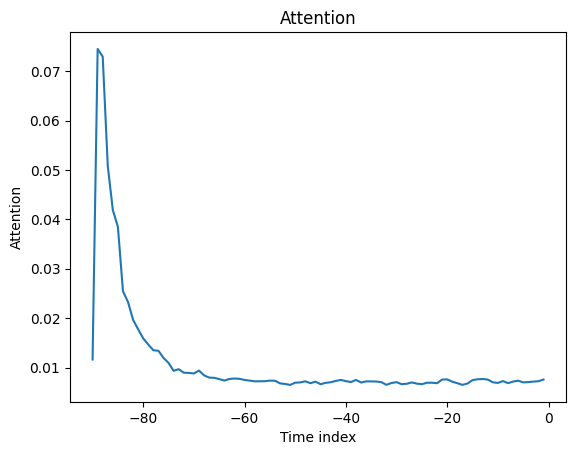

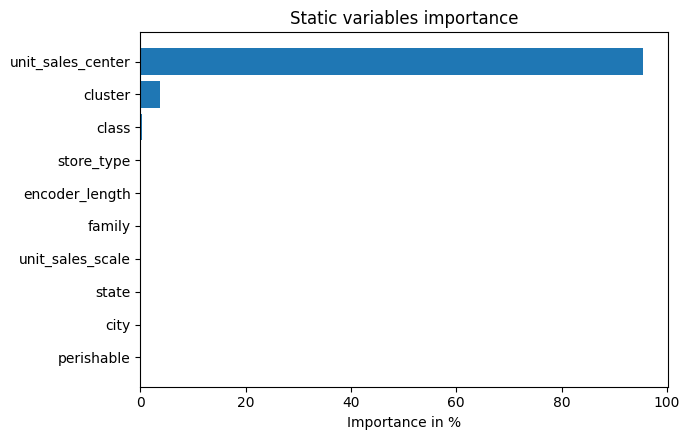

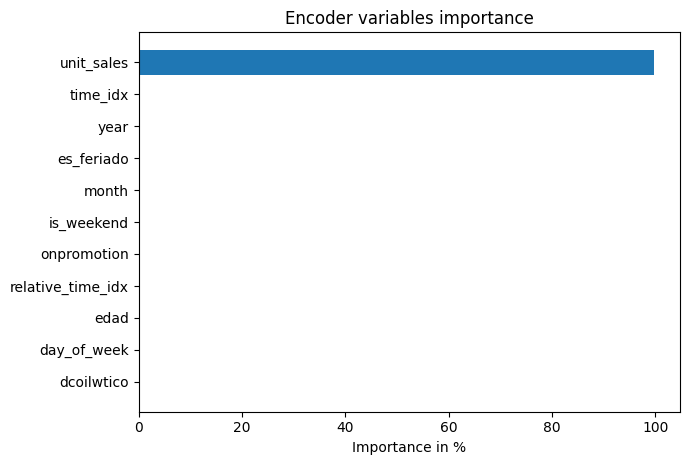

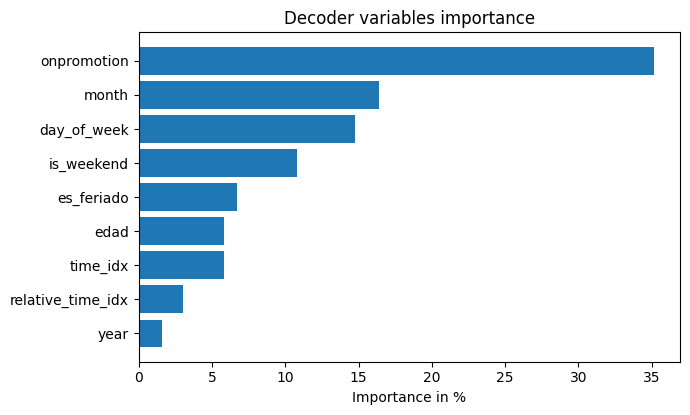

In [10]:
resultado_plot = tft_mejor.plot_interpretation(interpretation)

if isinstance(resultado_plot, dict):
    for nombre, fig in resultado_plot.items():
        fig.savefig(f'/content/drive/MyDrive/TFM/tft_interpretacion_{nombre}.png', dpi=150, bbox_inches='tight')
        print('Guardado:', nombre)
else:
    resultado_plot.savefig('/content/drive/MyDrive/TFM/tft_interpretacion.png', dpi=150, bbox_inches='tight')
    print('Guardado como una sola figura (revisar si incluye varios paneles adentro).')

Tipo: <class 'dict'> - Claves: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables']
attention: 0 barras, 1 líneas encontradas en el eje
Guardado: /content/drive/MyDrive/TFM/tft_interpretacion_attention_es.png


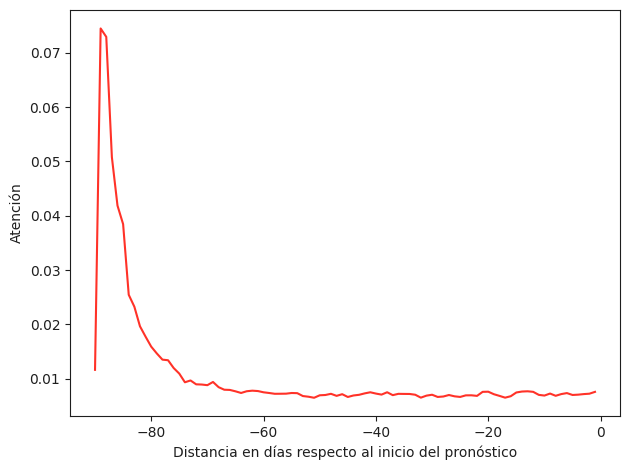

static_variables: 10 barras, 0 líneas encontradas en el eje
Guardado: /content/drive/MyDrive/TFM/tft_interpretacion_static_variables_es.png


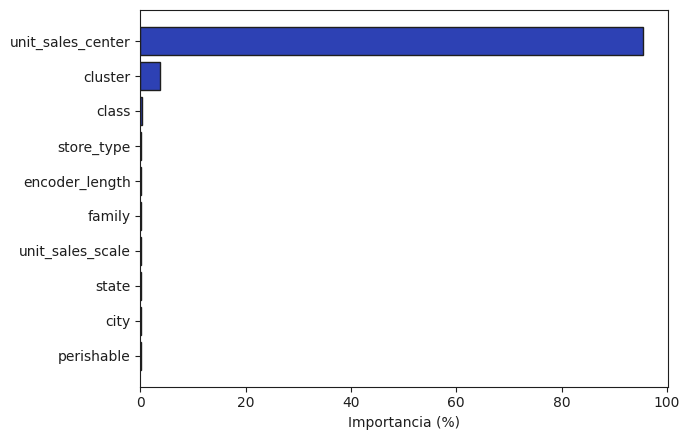

encoder_variables: 11 barras, 0 líneas encontradas en el eje
Guardado: /content/drive/MyDrive/TFM/tft_interpretacion_encoder_variables_es.png


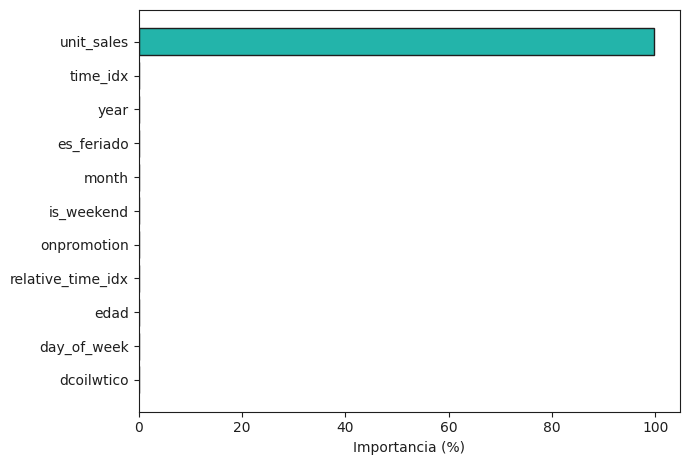

decoder_variables: 9 barras, 0 líneas encontradas en el eje
Guardado: /content/drive/MyDrive/TFM/tft_interpretacion_decoder_variables_es.png


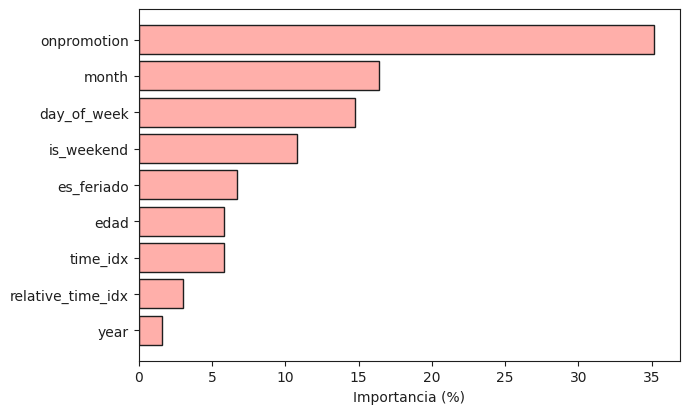

In [12]:
from IPython.display import display
import matplotlib.pyplot as plt

COLOR_ATENCION   = "#FF3228"
COLOR_ESTATICAS  = "#2D41B4"
COLOR_ENCODER    = "#23B4AA"
COLOR_DECODER    = "#FFAFAA"
TEXTO            = "#1E1E1E"

COLORES = {
    "attention": COLOR_ATENCION,
    "static_variables": COLOR_ESTATICAS,
    "encoder_variables": COLOR_ENCODER,
    "decoder_variables": COLOR_DECODER,
}

ETIQUETAS = {
    "attention": {"xlabel": "Distancia en días respecto al inicio del pronóstico", "ylabel": "Atención"},
    "static_variables": {"xlabel": "Importancia (%)"},
    "encoder_variables": {"xlabel": "Importancia (%)"},
    "decoder_variables": {"xlabel": "Importancia (%)"},
}

print("Tipo:", type(resultado_plot), "- Claves:", list(resultado_plot.keys()))

for key, fig in resultado_plot.items():
    ax = fig.axes[0]
    color = COLORES.get(key, COLOR_ATENCION)

    ax.set_title("")

    labels = ETIQUETAS.get(key, {})
    if "xlabel" in labels:
        ax.set_xlabel(labels["xlabel"], color=TEXTO)
    if "ylabel" in labels:
        ax.set_ylabel(labels["ylabel"], color=TEXTO)

    n_bars = len(ax.patches)
    n_lines = len(ax.lines)
    print(f"{key}: {n_bars} barras, {n_lines} líneas encontradas en el eje")

    for bar in ax.patches:
        bar.set_facecolor(color)
        bar.set_edgecolor(TEXTO)
    for line in ax.lines:
        line.set_color(color)

    ax.tick_params(colors=TEXTO)
    for spine in ax.spines.values():
        spine.set_color(TEXTO)

    fig.tight_layout()
    ruta = f'/content/drive/MyDrive/TFM/tft_interpretacion_{key}_es.png'
    fig.savefig(ruta, dpi=200, bbox_inches='tight')
    print("Guardado:", ruta)

    display(fig)